In [ ]:
from pathlib import Path
import sys
import json
import torch
import torch.nn as nn
from torchvision import models

PROJECT_ROOT_CANDIDATES = [
    parent.resolve()
    for parent in (Path.cwd(), *Path.cwd().parents)
    if (parent / "config.yaml").is_file()
    and (parent / "src" / "worm_species").is_dir()
]
if not PROJECT_ROOT_CANDIDATES:
    raise FileNotFoundError(
        "Could not locate repository root containing config.yaml and src/worm_species."
    )
PROJECT_ROOT = PROJECT_ROOT_CANDIDATES[0]
SOURCE_ROOT = PROJECT_ROOT / "src"
if str(SOURCE_ROOT) not in sys.path:
    sys.path.insert(0, str(SOURCE_ROOT))
# Preserve the historical single-task metadata implementation used by this checkpoint.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
RUN_DIR = PROJECT_ROOT / "outputs_slurm/node_local_sweep_20260706_122839/run_034/convnext_base__rel_path_seg__genus__5ec55a00"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)

# Load config and labels
with open(RUN_DIR / "config.json", "r") as f:
    cfg = json.load(f)

with open(RUN_DIR / "label_to_index.json", "r") as f:
    label_to_index = json.load(f)

index_to_label = {int(v): k for k, v in label_to_index.items()}
num_classes = len(index_to_label)

print("Classes:")
for i in sorted(index_to_label):
    print(i, index_to_label[i])

Device: cuda


In [ ]:
def build_efficientnet_b0(num_classes: int):
    model = models.efficientnet_b0(weights=None)

    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)

    return model


model = build_efficientnet_b0(num_classes)

ckpt = torch.load(RUN_DIR / "best_model.pt", map_location=DEVICE)

state_dict = ckpt["model_state"] if "model_state" in ckpt else ckpt

# Remove possible "module." prefix if trained with DataParallel/DDP
state_dict = {
    k.replace("module.", ""): v
    for k, v in state_dict.items()
}

model.load_state_dict(state_dict, strict=True)
model = model.to(DEVICE)
model.eval()

print("Loaded model successfully.")
print("Best validation macro-F1:", ckpt.get("best_val_macro_f1", "not stored"))

Detected architecture: convnext_base
Tasks: ['genus', 'species', 'age']
Classes per task: {'genus': 3, 'species': 8, 'age': 2}
Missing keys: ['features.0.0.weight', 'features.0.0.bias', 'features.0.1.weight', 'features.0.1.bias', 'features.1.0.layer_scale', 'features.1.0.block.0.weight', 'features.1.0.block.0.bias', 'features.1.0.block.2.weight', 'features.1.0.block.2.bias', 'features.1.0.block.3.weight', 'features.1.0.block.3.bias', 'features.1.0.block.5.weight', 'features.1.0.block.5.bias', 'features.1.1.layer_scale', 'features.1.1.block.0.weight', 'features.1.1.block.0.bias', 'features.1.1.block.2.weight', 'features.1.1.block.2.bias', 'features.1.1.block.3.weight', 'features.1.1.block.3.bias', 'features.1.1.block.5.weight', 'features.1.1.block.5.bias', 'features.1.2.layer_scale', 'features.1.2.block.0.weight', 'features.1.2.block.0.bias', 'features.1.2.block.2.weight', 'features.1.2.block.2.bias', 'features.1.2.block.3.weight', 'features.1.2.block.3.bias', 'features.1.2.block.5.weig

In [18]:
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np

IMAGE_SIZE = cfg["data"]["image_size"]

preprocess = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])


def load_image_for_cam(image_path: Path):
    image = Image.open(image_path).convert("RGB")
    x = preprocess(image).unsqueeze(0)
    return image, x

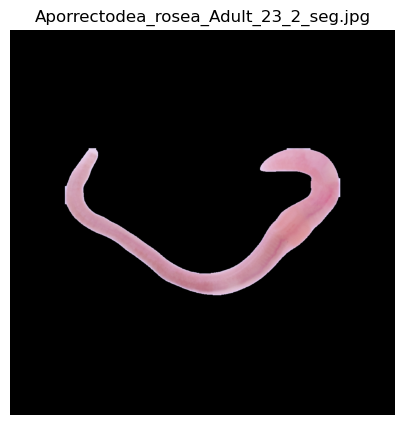

In [19]:
IMAGE_PATH = Path("/mnt/extssd/Earthworms/petridish-worm-images/01_Segmented/Aporrectodea_rosea_Adult_23/Aporrectodea_rosea_Adult_23_2/Aporrectodea_rosea_Adult_23_2_seg.jpg")

image, x = load_image_for_cam(IMAGE_PATH)
x = x.to(DEVICE)

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.axis("off")
plt.title(IMAGE_PATH.name)
plt.show()

In [20]:
target_layer = model.features[-1]

In [21]:
import torch.nn.functional as F

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        self.forward_handle = target_layer.register_forward_hook(self._forward_hook)
        self.backward_handle = target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, input, output):
        self.activations = output.detach()

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def remove_hooks(self):
        self.forward_handle.remove()
        self.backward_handle.remove()

    def __call__(self, x, class_idx=None):
        self.model.zero_grad(set_to_none=True)

        logits = self.model(x)

        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()

        score = logits[:, class_idx]
        score.backward()

        # activations: [B, C, H, W]
        # gradients:   [B, C, H, W]
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)

        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)

        cam = F.interpolate(
            cam,
            size=x.shape[2:],
            mode="bilinear",
            align_corners=False,
        )

        cam = cam.squeeze().cpu().numpy()

        # Normalise heatmap to [0, 1]
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        probs = torch.softmax(logits.detach(), dim=1).squeeze().cpu().numpy()

        return cam, class_idx, probs

In [22]:
import cv2

target_layer = model.features[-1]
gradcam = GradCAM(model, target_layer)

cam, pred_idx, probs = gradcam(x)

pred_label = index_to_label[pred_idx]
pred_prob = probs[pred_idx]

print("Predicted class:", pred_label)
print("Predicted probability:", pred_prob)

top_probs = sorted(
    [(index_to_label[i], float(p)) for i, p in enumerate(probs)],
    key=lambda z: z[1],
    reverse=True,
)

print("\nTop probabilities:")
for label, p in top_probs:
    print(f"{label}: {p:.4f}")

Predicted class: Aporrectodea_rosea
Predicted probability: 0.99999857

Top probabilities:
Aporrectodea_rosea: 1.0000
Aporrectodea_caliginosa_tuberculata: 0.0000
Aporrectodea_tuberculata: 0.0000
Allolobophora_chlorotica: 0.0000
Aporrectodea_longa: 0.0000
Lumbricus_sp: 0.0000


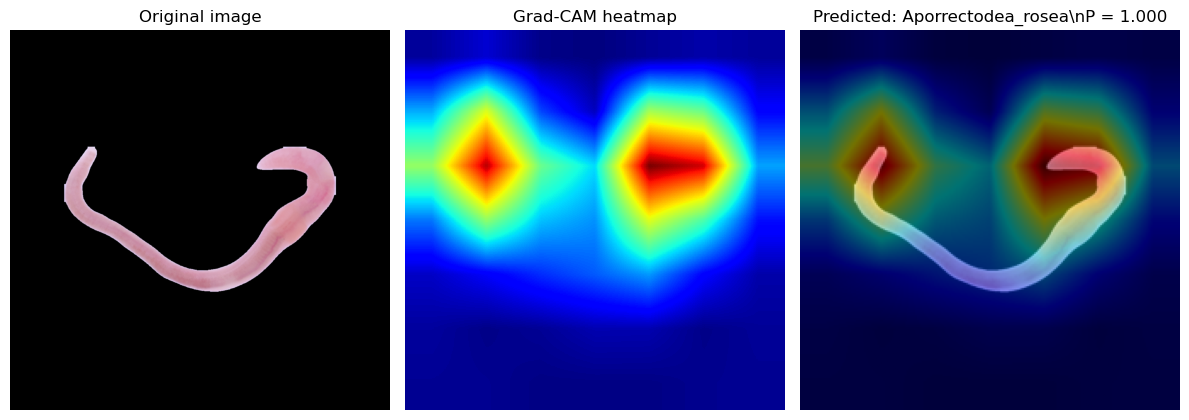

In [23]:
def overlay_cam_on_image(pil_image, cam, alpha=0.45):
    image = pil_image.resize((cam.shape[1], cam.shape[0]))
    image_np = np.array(image).astype(np.float32) / 255.0

    heatmap = cv2.applyColorMap(
        np.uint8(255 * cam),
        cv2.COLORMAP_JET,
    )
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    heatmap = heatmap.astype(np.float32) / 255.0

    overlay = (1 - alpha) * image_np + alpha * heatmap
    overlay = np.clip(overlay, 0, 1)

    return overlay


overlay = overlay_cam_on_image(image, cam)

plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.axis("off")
plt.title("Original image")

plt.subplot(1, 3, 2)
plt.imshow(cam, cmap="jet")
plt.axis("off")
plt.title("Grad-CAM heatmap")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.axis("off")
plt.title(f"Predicted: {pred_label}\\nP = {pred_prob:.3f}")

plt.tight_layout()
plt.show()

gradcam.remove_hooks()

In [24]:
# -----------------------------
# GRAD-CAM: ALL SPECIES + RANDOM EXAMPLES
# -----------------------------
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import matplotlib.cm as cm
from src.dataset import prepare_metadata

# Re-load metadata if needed
metadata_csv = Path(cfg["data"]["metadata_csv"])
root_dir = Path(cfg["data"]["root_dir"])
image_col = cfg["data"]["image_col"]
target_col = cfg["data"]["target_col"]


df = prepare_metadata(cfg=cfg)
# Use the final EfficientNet feature block
target_layer = model.features[-1]


def resolve_image_path(row):
    """Resolve relative or absolute image paths."""
    p = Path(row[image_col])
    if p.is_absolute():
        return p
    return root_dir / p


def load_row_image(row):
    """Load image and preprocessed tensor from a dataframe row."""
    image_path = resolve_image_path(row)
    image = Image.open(image_path).convert("RGB")
    x = preprocess(image).unsqueeze(0).to(DEVICE)
    return image, x, image_path


def overlay_cam_on_image_matplotlib(pil_image, cam_arr, alpha=0.45):
    """
    Overlay Grad-CAM heatmap on image without requiring OpenCV.
    cam_arr should be normalised to [0, 1].
    """
    image = pil_image.resize((cam_arr.shape[1], cam_arr.shape[0]))
    image_np = np.asarray(image).astype(np.float32) / 255.0

    heatmap = cm.get_cmap("jet")(cam_arr)[..., :3]  # RGBA -> RGB
    overlay = (1 - alpha) * image_np + alpha * heatmap
    overlay = np.clip(overlay, 0, 1)

    return overlay


def predict_image(x):
    """Return predicted class, probability, and full probability vector."""
    model.eval()
    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1).squeeze().cpu().numpy()

    pred_idx = int(np.argmax(probs))
    pred_label = index_to_label[pred_idx]
    pred_prob = float(probs[pred_idx])

    return pred_idx, pred_label, pred_prob, probs


def get_cam_for_class(x, class_idx):
    """Compute Grad-CAM for a specific target class."""
    gradcam = GradCAM(model, target_layer)
    cam_arr, _, probs = gradcam(x, class_idx=class_idx)
    gradcam.remove_hooks()
    return cam_arr, probs

Initial dataset size: 6209
After removing invalid images, dataset size: 6207

Classes retained:
species_label
Aporrectodea_caliginosa_tuberculata    388
Allolobophora_chlorotica               176
Lumbricus_sp                           165
Aporrectodea_longa                     159
Aporrectodea_tuberculata               105
Aporrectodea_rosea                      52
Name: barcode, dtype: int64


Image: /mnt/extssd/Earthworms/petridish-worm-images/01_Segmented/Aporrectodea_caliginosa_tuberculata_Juvenile_111/Aporrectodea_caliginosa_tuberculata_Juvenile_111_6/Aporrectodea_caliginosa_tuberculata_Juvenile_111_6_seg.jpg
True label: Aporrectodea_caliginosa_tuberculata_Juvenile_111
Predicted label: Aporrectodea_caliginosa_tuberculata
Predicted probability: 0.999


/tmp/ipykernel_1799853/1644297843.py:49: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  heatmap = cm.get_cmap("jet")(cam_arr)[..., :3]  # RGBA -> RGB


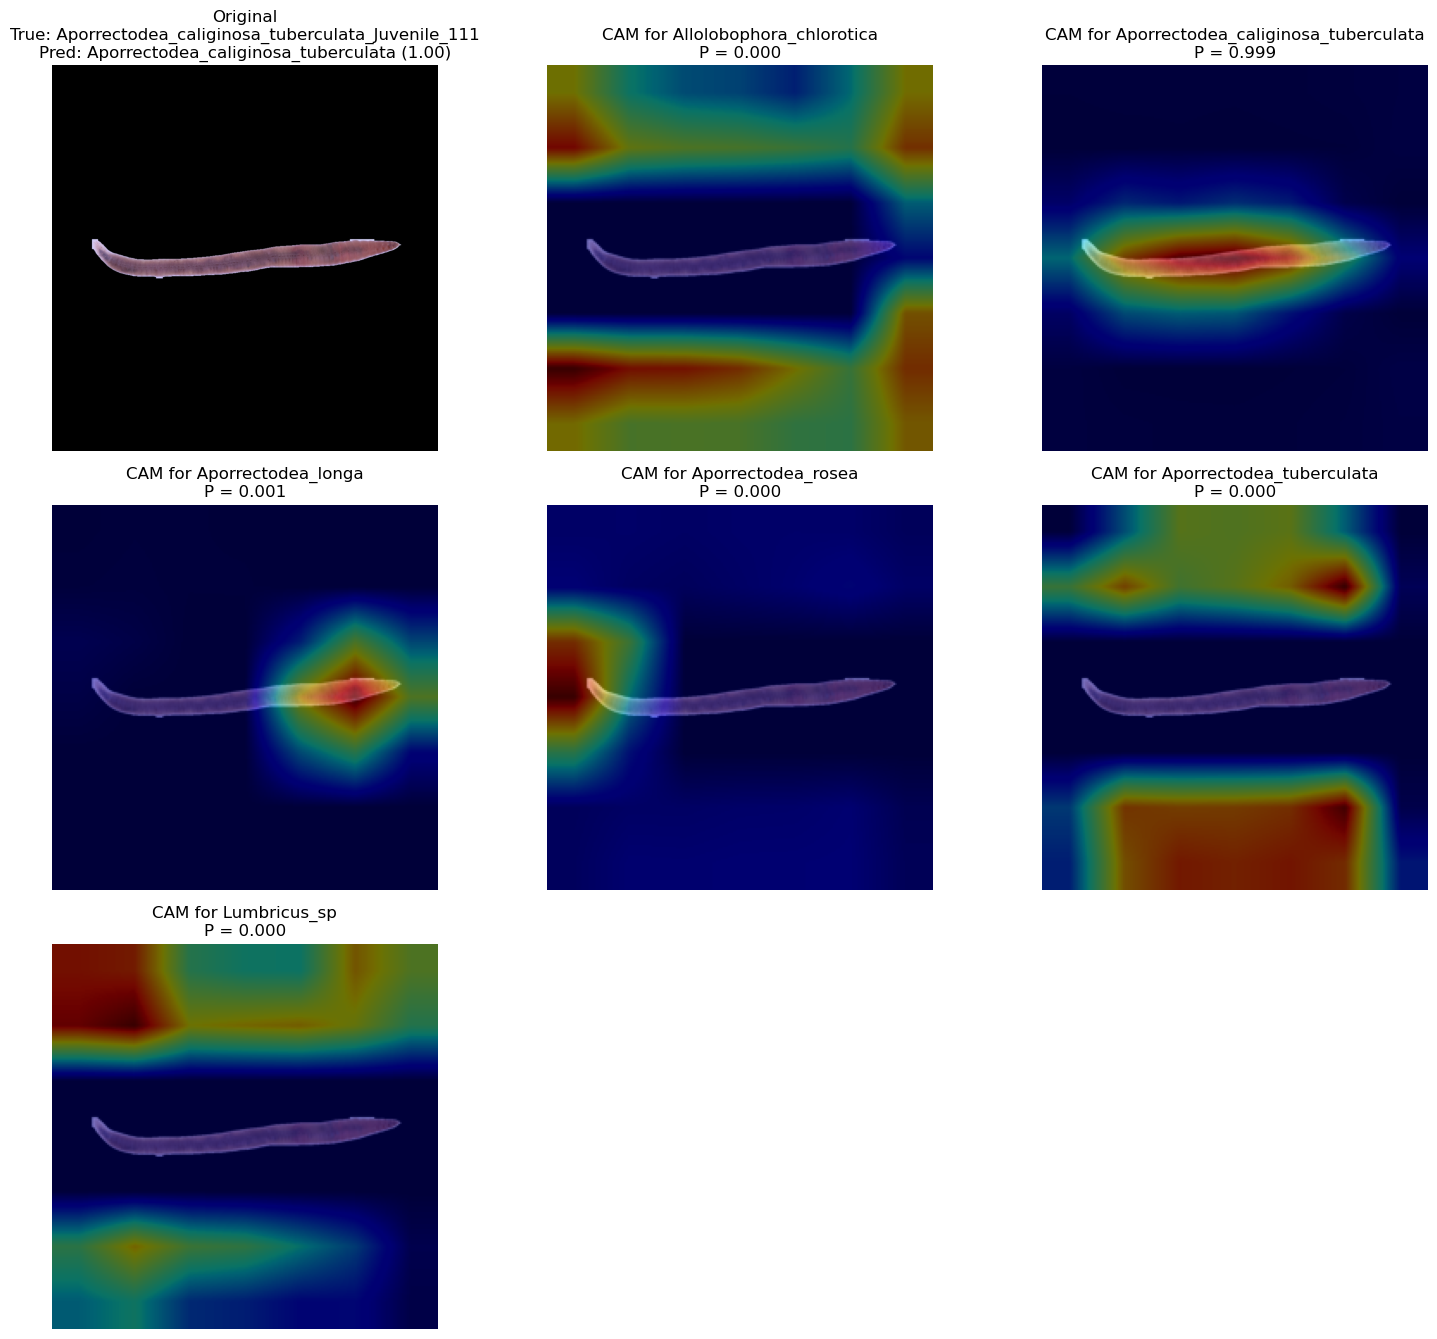

In [31]:
# -----------------------------
# ONE IMAGE: HEATMAP FOR EVERY SPECIES
# -----------------------------

# Choose one random image
row = df.sample(1, random_state=71).iloc[0]

image, x, image_path = load_row_image(row)
true_label = row['barcode']

pred_idx, pred_label, pred_prob, probs = predict_image(x)

print("Image:", image_path)
print("True label:", true_label)
print("Predicted label:", pred_label)
print(f"Predicted probability: {pred_prob:.3f}")

# Plot original + one Grad-CAM per class
n_classes = len(index_to_label)
n_cols = 3
n_rows = int(np.ceil((n_classes + 1) / n_cols))

plt.figure(figsize=(5 * n_cols, 4.5 * n_rows))

# Original image
plt.subplot(n_rows, n_cols, 1)
plt.imshow(image)
plt.axis("off")
plt.title(f"Original\nTrue: {true_label}\nPred: {pred_label} ({pred_prob:.2f})")

# Class-specific heatmaps
for plot_i, class_idx in enumerate(sorted(index_to_label.keys()), start=2):
    class_label = index_to_label[class_idx]

    cam_arr, probs = get_cam_for_class(x, class_idx=class_idx)
    overlay = overlay_cam_on_image_matplotlib(image, cam_arr)

    plt.subplot(n_rows, n_cols, plot_i)
    plt.imshow(overlay)
    plt.axis("off")

    class_prob = probs[class_idx]
    plt.title(f"CAM for {class_label}\nP = {class_prob:.3f}")

plt.tight_layout()
plt.show()

In [26]:
# -----------------------------
# RANDOM EXAMPLES PER TRUE SPECIES
# -----------------------------

N_PER_SPECIES = 1
RANDOM_STATE = 42

sampled_rows = (
    df
    .groupby(target_col, group_keys=False)
    .apply(lambda g: g.sample(
        n=min(N_PER_SPECIES, len(g)),
        random_state=RANDOM_STATE
    ))
    .reset_index(drop=True)
)

print("Number of sampled examples:", len(sampled_rows))
display(sampled_rows[[image_col, target_col]].head())

Number of sampled examples: 6


/tmp/ipykernel_1799853/3104009907.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(


,rel_path_seg,species_label
0,01_Segmented/Allolobophora_chlorotica_Adult_18...,Allolobophora_chlorotica
1,01_Segmented/Aporrectodea_caliginosa_tubercula...,Aporrectodea_caliginosa_tuberculata
2,01_Segmented/Aporrectodea_longa_Juvenile_64/Ap...,Aporrectodea_longa
3,01_Segmented/Aporrectodea_rosea_Juvenile_16/Ap...,Aporrectodea_rosea
4,01_Segmented/Aporrectodea_tuberculata_Adult_57...,Aporrectodea_tuberculata


/tmp/ipykernel_1799853/1644297843.py:49: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  heatmap = cm.get_cmap("jet")(cam_arr)[..., :3]  # RGBA -> RGB


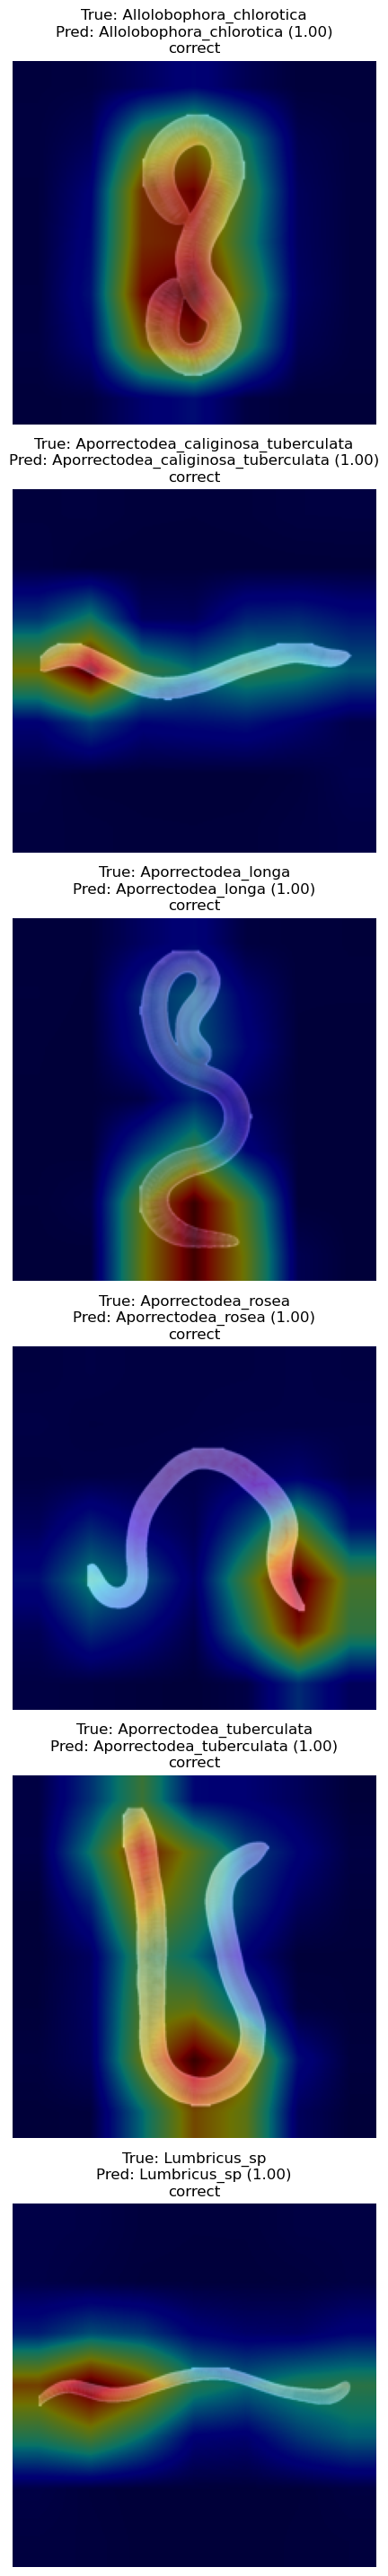

In [27]:
# -----------------------------
# PLOT RANDOM EXAMPLES WITH PREDICTED-CLASS GRAD-CAM
# -----------------------------

n_examples = len(sampled_rows)
n_cols = N_PER_SPECIES
n_rows = int(np.ceil(n_examples / n_cols))

plt.figure(figsize=(5 * n_cols, 4.8 * n_rows))

for i, (_, row) in enumerate(sampled_rows.iterrows(), start=1):
    image, x, image_path = load_row_image(row)
    true_label = row[target_col]

    pred_idx, pred_label, pred_prob, probs = predict_image(x)

    # CAM for predicted class
    cam_arr, _ = get_cam_for_class(x, class_idx=pred_idx)
    overlay = overlay_cam_on_image_matplotlib(image, cam_arr)

    correct = true_label == pred_label
    status = "correct" if correct else "wrong"

    plt.subplot(n_rows, n_cols, i)
    plt.imshow(overlay)
    plt.axis("off")
    plt.title(
        f"True: {true_label}\n"
        f"Pred: {pred_label} ({pred_prob:.2f})\n"
        f"{status}"
    )

plt.tight_layout()
plt.show()

/tmp/ipykernel_1799853/1644297843.py:49: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  heatmap = cm.get_cmap("jet")(cam_arr)[..., :3]  # RGBA -> RGB


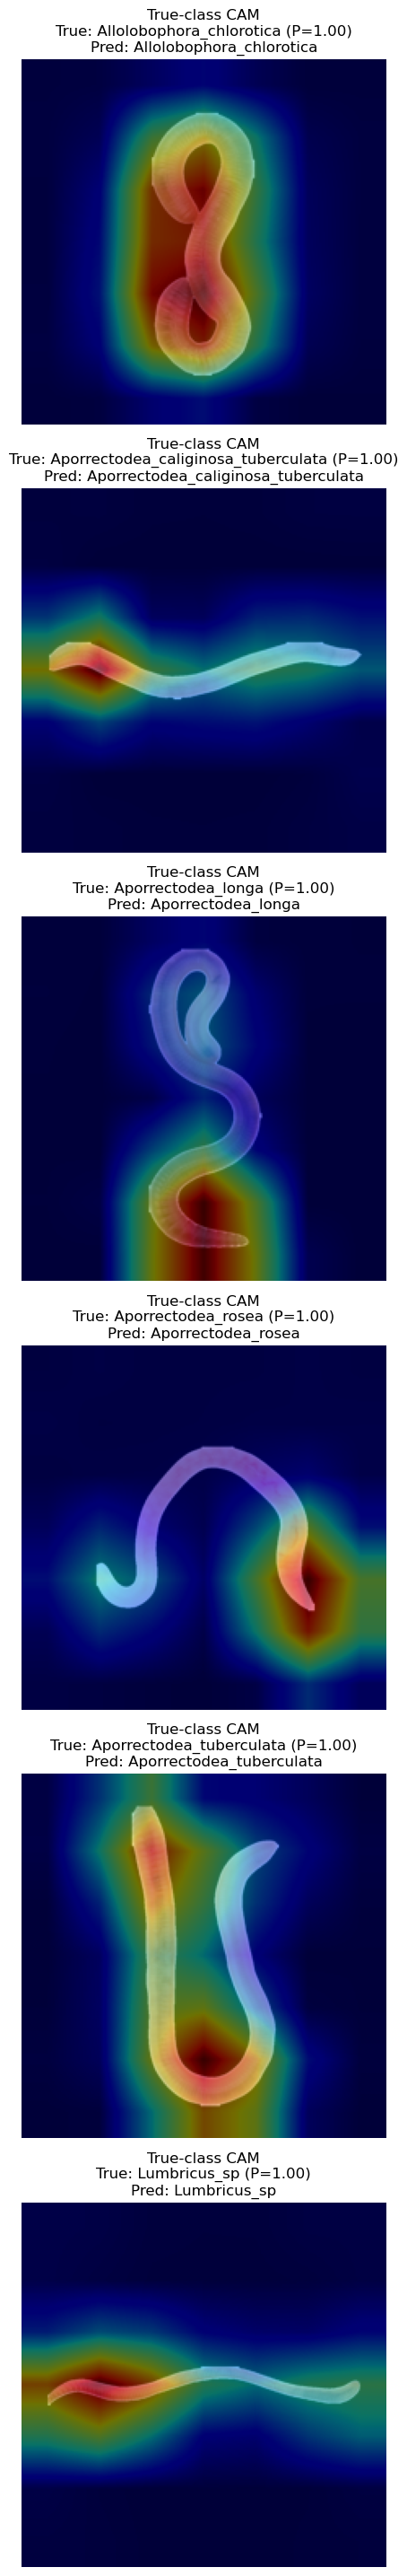

In [28]:
# -----------------------------
# RANDOM EXAMPLES WITH TRUE-CLASS GRAD-CAM
# -----------------------------

plt.figure(figsize=(5 * n_cols, 4.8 * n_rows))

for i, (_, row) in enumerate(sampled_rows.iterrows(), start=1):
    image, x, image_path = load_row_image(row)
    true_label = row[target_col]
    true_idx = label_to_index[true_label]

    pred_idx, pred_label, pred_prob, probs = predict_image(x)

    # CAM for true class
    cam_arr, _ = get_cam_for_class(x, class_idx=true_idx)
    overlay = overlay_cam_on_image_matplotlib(image, cam_arr)

    true_prob = probs[true_idx]

    plt.subplot(n_rows, n_cols, i)
    plt.imshow(overlay)
    plt.axis("off")
    plt.title(
        f"True-class CAM\n"
        f"True: {true_label} (P={true_prob:.2f})\n"
        f"Pred: {pred_label}"
    )

plt.tight_layout()
plt.show()

/tmp/ipykernel_1799853/1644297843.py:49: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  heatmap = cm.get_cmap("jet")(cam_arr)[..., :3]  # RGBA -> RGB


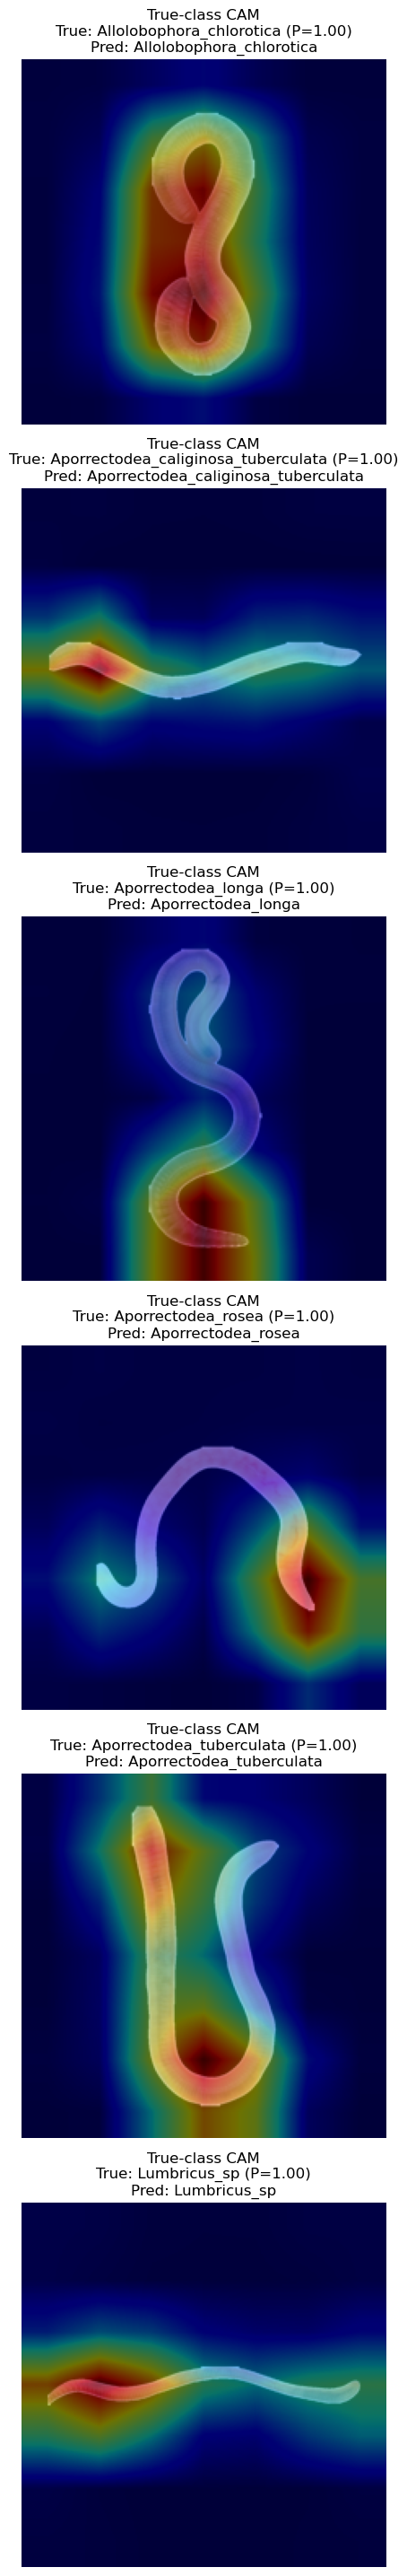

In [29]:
# -----------------------------
# RANDOM EXAMPLES WITH TRUE-CLASS GRAD-CAM
# -----------------------------

plt.figure(figsize=(5 * n_cols, 4.8 * n_rows))

for i, (_, row) in enumerate(sampled_rows.iterrows(), start=1):
    image, x, image_path = load_row_image(row)
    true_label = row[target_col]
    true_idx = label_to_index[true_label]

    pred_idx, pred_label, pred_prob, probs = predict_image(x)

    # CAM for true class
    cam_arr, _ = get_cam_for_class(x, class_idx=true_idx)
    overlay = overlay_cam_on_image_matplotlib(image, cam_arr)

    true_prob = probs[true_idx]

    plt.subplot(n_rows, n_cols, i)
    plt.imshow(overlay)
    plt.axis("off")
    plt.title(
        f"True-class CAM\n"
        f"True: {true_label} (P={true_prob:.2f})\n"
        f"Pred: {pred_label}"
    )

plt.tight_layout()
plt.show()